# BINN Gene Feature Extraction v2: Dual-Stream Architecture

This notebook extends v1 with a **Dual-Stream BINN** that processes all 18k genes:

- **Stream 1 — Pathway BINN** (~10k genes with Reactome annotations): sparse masked layers constrained by the Reactome hierarchy, exactly as in v1.
- **Stream 2 — Dense MLP** (~7.6k genes without Reactome annotations): a small two-layer MLP with no pathway constraint.

Both streams are merged at a bottleneck before predicting all 44 protein abundances. SHAP is run on the mapped (pathway) stream only; unmapped genes are ranked separately by their dense-stream gradient importance.

```
Mapped genes (~10k)        Unmapped genes (~7.6k)
      │                           │
      ▼                           ▼
 BINN pathway layers         Dense MLP
 (sparse, Reactome)          (2 hidden layers)
      │                           │
      └──────────┬────────────────┘
                 ▼
          Merged bottleneck
                 ▼
        Protein predictions (44)
```


## 0. Environment Setup

In [1]:
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg, imp in [('anndata', 'anndata'), ('scikit-misc', 'skmisc'),
                 ('scanpy', 'scanpy'), ('binn', 'binn'), ('shap', 'shap'),
                 ('kneed', 'kneed'), ('networkx', 'networkx')]:
    try:
        __import__(imp)
    except ImportError:
        print(f'Installing {pkg}...')
        _install(pkg)

print('All packages available.')


All packages available.


In [2]:
import gc
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import requests
from tqdm.auto import tqdm

import anndata as ad
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import shap

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.12.1+cu130


In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(DEVICE)

True
NVIDIA L4
cuda


## 1. Configuration

In [4]:
# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR       = Path('/home/ubuntu/data')
TRAIN_RNA_PATH = BASE_DIR / 'train_rna.h5ad'
TRAIN_PRO_PATH = BASE_DIR / 'train_pro.h5ad'
OUTPUT_DIR     = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BINN_DATA_DIR  = BASE_DIR / 'binn_data'

# ── Preprocessing ──────────────────────────────────────────────────────────────
MIN_COUNTS_GENE  = 5
NORMALIZE_TARGET = 1e4

# ── BINN architecture ──────────────────────────────────────────────────────────
N_BINN_LAYERS  = 4
DROPOUT_RATE   = 0.2

# ── Training ───────────────────────────────────────────────────────────────────
BATCH_SIZE      = 4096
N_EPOCHS        = 50
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-4
VAL_SPLIT       = 0.15
EARLY_STOP_PAT  = 10

# SHAP
N_SHAP_BACKGROUND = 256
N_SHAP_EXPLAIN    = 512

# ── Gene selection — set one, leave other None ─────────────────────────────────
N_GENES_FIXED   = None   # e.g. 3000 to force a fixed output
CUMULATIVE_FRAC = 0.90   # data-driven: keep genes covering 90% of SHAP importance

print('Configuration loaded.')

Configuration loaded.


### 1.1 Reactome Reference Files

Run this cell once; files are saved to Google Drive and persist across sessions.

In [5]:
BINN_DATA_DIR.mkdir(parents=True, exist_ok=True)

_reactome_files = {
    'uniprot_2_reactome_2025_01_14.txt':
        'https://reactome.org/download/current/UniProt2Reactome.txt',
    'reactome_pathways_relation_2025_01_14.txt':
        'https://reactome.org/download/current/ReactomePathwaysRelation.txt',
    'reactome_pathways_names_2025_01_21.txt':
        'https://reactome.org/download/current/ReactomePathways.txt',
}

for fname, url in _reactome_files.items():
    dest = BINN_DATA_DIR / fname
    if not dest.exists():
        print(f'Downloading {fname} ...')
        os.system(f'wget -q "{url}" -O "{dest}"')
    else:
        print(f'Found (cached): {fname}')

found = list(BINN_DATA_DIR.glob('*.txt'))
print(f'\n{len(found)} Reactome files ready.')


Found (cached): uniprot_2_reactome_2025_01_14.txt
Found (cached): reactome_pathways_relation_2025_01_14.txt
Found (cached): reactome_pathways_names_2025_01_21.txt

3 Reactome files ready.


## 2. Data Loading and Preprocessing

All three functions are memory-efficient:
- `load_spatial_data` uses `backed='r'` (memory-mapped) to filter on obs metadata before pulling any matrix into RAM.
- `preprocess_rna` selects HVGs on raw sparse counts, subsets the gene axis **before** normalization, then normalizes only the small (N × 3,000) matrix.
- `preprocess_protein` performs CLR normalization in 500-row chunks so the dense slice is never larger than 500 × 44.

In [6]:
def load_spatial_data(rna_path, pro_path=None, in_tissue_only=True):
    """
    Load RNA (and optionally protein) AnnData objects.

    Uses memory-mapped access to filter on obs metadata before loading
    any expression matrix into RAM. Returns sparse CSR matrices.
    """
    print(f'Loading RNA from {rna_path} ...')
    rna = ad.read_h5ad(rna_path, backed='r')
    print(f'  Shape: {rna.shape}  (bins × genes)')

    rna_obs = (rna.obs_names[rna.obs['in_tissue'] == 1]
               if in_tissue_only and 'in_tissue' in rna.obs.columns
               else rna.obs_names)

    pro = None
    if pro_path is not None:
        print(f'Loading protein from {pro_path} ...')
        pro = ad.read_h5ad(pro_path, backed='r')
        print(f'  Shape: {pro.shape}  (bins × markers)')

        pro_obs = (pro.obs_names[pro.obs['in_tissue'] == 1]
                   if in_tissue_only and 'in_tissue' in pro.obs.columns
                   else pro.obs_names)

        common = rna_obs.intersection(pro_obs)
        print(f'  Common in-tissue bins: {len(common)}')

        rna = rna[common].to_memory()
        pro = pro[common].to_memory()
    else:
        rna = rna[rna_obs].to_memory()

    if not sp.issparse(rna.X):
        rna.X = sp.csr_matrix(rna.X)
    if pro is not None and not sp.issparse(pro.X):
        pro.X = sp.csr_matrix(pro.X)

    print(f'  RNA loaded: {rna.shape}')
    return rna, pro


def preprocess_rna(adata, normalize_target=1e4, min_counts_gene=5):
    """
    RNA preprocessing. filter_cells is omitted as in_tissue filtering
    in load_spatial_data already removes empty/off-tissue bins.
    filter_genes removes genes with negligible expression across all bins.
    """
    print('Preprocessing RNA ...')

    if not sp.issparse(adata.X):
        adata.X = sp.csr_matrix(adata.X)

    sc.pp.filter_genes(adata, min_counts=min_counts_gene)
    print(f'  After gene QC filter: {adata.shape}')

    sc.pp.normalize_total(adata, target_sum=normalize_target, inplace=True)
    sc.pp.log1p(adata, chunked=True, chunk_size=10000)
    adata.X = adata.X.tocsr()

    all_genes = adata.var_names.tolist()
    print(f'  Preprocessing complete: {adata.shape}')
    return adata, all_genes


def preprocess_protein(adata, chunk_size=500):
    """
    Centred log-ratio (CLR) normalisation for CODEX protein data.

    Processes the matrix in `chunk_size`-row slices so that only a small
    dense block is ever resident in RAM (chunk_size × n_markers).
    Z-scores are applied in-place after CLR.
    """
    print('Preprocessing protein (CLR normalisation) ...')

    n_bins, n_markers = adata.shape
    X_clr = np.empty((n_bins, n_markers), dtype=np.float32)

    for start in range(0, n_bins, chunk_size):
        end   = min(start + chunk_size, n_bins)
        chunk = adata.X[start:end]
        if sp.issparse(chunk):
            chunk = chunk.toarray()
        chunk  = chunk.astype(np.float32) + 1.0
        geom   = np.exp(np.mean(np.log(chunk), axis=1, keepdims=True))
        X_clr[start:end] = np.log(chunk / geom)

    mean_ = X_clr.mean(axis=0, keepdims=True)
    std_  = X_clr.std(axis=0,  keepdims=True) + 1e-8
    X_clr -= mean_
    X_clr /= std_

    adata      = adata.copy()   # copy obs/var metadata only
    adata.X    = X_clr
    adata.uns['protein_clr_mean'] = mean_
    adata.uns['protein_clr_std']  = std_

    print(f'  Protein matrix shape: {adata.X.shape}')
    return adata


In [7]:
rna_train, pro_train = load_spatial_data(TRAIN_RNA_PATH, TRAIN_PRO_PATH)

rna_train, all_genes = preprocess_rna(
    rna_train,
    normalize_target = NORMALIZE_TARGET,
    min_counts_gene  = MIN_COUNTS_GENE,
)

pro_train = preprocess_protein(pro_train)

common_obs = rna_train.obs_names.intersection(pro_train.obs_names)
if len(common_obs) < len(rna_train):
    print(f'Re-aligning after QC: {len(common_obs)} common bins')
    rna_train = rna_train[common_obs]
    pro_train = pro_train[common_obs]

print(f'\nFinal shapes:')
print(f'  RNA train    : {rna_train.shape}')
print(f'  Protein train: {pro_train.shape}')


Loading RNA from /home/ubuntu/data/train_rna.h5ad ...
  Shape: (166186, 18085)  (bins × genes)
Loading protein from /home/ubuntu/data/train_pro.h5ad ...
  Shape: (166186, 44)  (bins × markers)
  Common in-tissue bins: 166186
  RNA loaded: (166186, 18085)
Preprocessing RNA ...
  After gene QC filter: (166186, 18033)
  Preprocessing complete: (166186, 18033)
Preprocessing protein (CLR normalisation) ...
  Protein matrix shape: (166186, 44)

Final shapes:
  RNA train    : (166186, 18033)
  Protein train: (166186, 44)


## 3. Gene → Reactome Pathway Mapping

Converts HGNC gene symbols to Reactome pathway identifiers via two steps:
1. **MyGene.info REST API**: gene symbol → UniProt Swiss-Prot accession (batched, cached).
2. **Reactome flat files**: UniProt → pathway ID → parent pathway ID (bundled with the `binn` package).

The result is cached to disk so subsequent runs skip the API calls.

In [8]:
def fetch_gene_to_uniprot_batch(gene_symbols, batch_size=200):
    """
    Convert HGNC gene symbols to UniProt Swiss-Prot accessions via MyGene.info.

    Parameters
    ----------
    gene_symbols : list[str]
    batch_size   : int  — number of symbols per API request

    Returns
    -------
    dict[str, list[str]]  — {gene_symbol: [uniprot_id, ...]}
    """
    print(f'Querying MyGene.info for {len(gene_symbols)} gene symbols...')
    symbol_to_uniprot = {}
    url     = 'https://mygene.info/v3/query'
    headers = {'Content-Type': 'application/x-www-form-urlencoded'}

    for i in tqdm(range(0, len(gene_symbols), batch_size), desc='Gene→UniProt'):
        batch   = gene_symbols[i : i + batch_size]
        payload = {'q': ','.join(batch), 'scopes': 'symbol',
                   'fields': 'uniprot', 'species': 'human', 'size': batch_size}
        try:
            resp = requests.post(url, data=payload, headers=headers, timeout=30)
            resp.raise_for_status()
            for hit in resp.json():
                sym = hit.get('query', '')
                if 'uniprot' in hit and 'Swiss-Prot' in hit['uniprot']:
                    acc = hit['uniprot']['Swiss-Prot']
                    symbol_to_uniprot[sym] = [acc] if isinstance(acc, str) else acc
        except Exception as e:
            print(f'  Warning: batch {i // batch_size} failed: {e}')

    print(f'  Mapped {len(symbol_to_uniprot)}/{len(gene_symbols)} genes to UniProt.')
    return symbol_to_uniprot


def build_gene_reactome_mapping(gene_symbols, binn_data_dir, cache_path=None):
    """
    Build the gene → Reactome pathway table used to define BINN connectivity.

    Results are written to `cache_path` (Parquet) on first run and loaded
    from cache on subsequent runs.

    Returns
    -------
    gene_to_pathway  : pd.DataFrame  — columns [input, translation, ...]
    pathway_relations: list[tuple]   — (child_pathway, parent_pathway)
    covered_genes    : list[str]     — gene symbols with at least one pathway
    """
    cache_path = cache_path or OUTPUT_DIR / 'gene_reactome_mapping.parquet'

    if Path(cache_path).exists():
        print(f'Loading cached mapping from {cache_path}')
        gene_to_pathway = pd.read_csv(cache_path)
    else:
        up2r = pd.read_csv(
            binn_data_dir / 'uniprot_2_reactome_2025_01_14.txt',
            sep='\t', header=None,
            names=['input', 'translation', 'url', 'name', 'evidence', 'species'],
        )
        up2r_human = up2r[up2r['species'] == 'Homo sapiens']
        sym2up     = fetch_gene_to_uniprot_batch(gene_symbols)

        rows = []
        for sym, uids in sym2up.items():
            for uid in uids:
                matches = up2r_human[up2r_human['input'] == uid].copy()
                if len(matches):
                    matches['input'] = sym
                    rows.append(matches)

        if not rows:
            raise RuntimeError(
                'No genes mapped to Reactome. Check network connectivity.')

        gene_to_pathway = pd.concat(rows, ignore_index=True).drop_duplicates()
        gene_to_pathway.to_csv(cache_path)
        print(f'Mapping saved to {cache_path}')

    p_rel = pd.read_csv(
        binn_data_dir / 'reactome_pathways_relation_2025_01_14.txt',
        sep='\t', header=None, names=['target', 'source'],
    )
    p_rel_human = p_rel[
        p_rel['target'].str.startswith('R-HSA') &
        p_rel['source'].str.startswith('R-HSA')
    ]
    pathway_relations = list(p_rel_human.itertuples(index=False, name=None))
    covered_genes     = gene_to_pathway['input'].unique().tolist()

    print(f'  Genes with Reactome mapping : {len(covered_genes)}')
    print(f'  Human pathway relations     : {len(pathway_relations)}')
    return gene_to_pathway, pathway_relations, covered_genes


In [9]:
gene_to_pathway_df, pathway_relations, covered_genes = build_gene_reactome_mapping(
    all_genes,           # <── was hvg_genes
    binn_data_dir = BINN_DATA_DIR,
)


Loading cached mapping from /home/ubuntu/data/outputs/gene_reactome_mapping.parquet
  Genes with Reactome mapping : 10418
  Human pathway relations     : 2899


## 4. Dual-Stream BINN Architecture

**Stream 1 — Pathway BINN**: genes with Reactome annotations flow through sparse `MaskedLinear` layers whose connectivity mirrors the Reactome hierarchy. Each weight outside the biological graph is permanently zeroed.

**Stream 2 — Dense MLP**: genes without Reactome annotations flow through a small two-layer MLP. These genes have no pathway constraint but still contribute to protein prediction.

Both streams are concatenated at the bottleneck and passed through a shared prediction head.


In [10]:
def build_pathway_layers(gene_symbols_subset, gene_to_pathway_df,
                         pathway_relations, n_layers):
    """
    Construct sparse connectivity masks for each BINN pathway layer.

    Parameters
    ----------
    gene_symbols_subset : list[str]  — Reactome-mapped genes
    gene_to_pathway_df  : pd.DataFrame
    pathway_relations   : list[tuple] — (child, parent) pathway pairs
    n_layers            : int

    Returns
    -------
    layer_nodes : list[list[str]]
    masks       : list[torch.BoolTensor]
    """
    import networkx as nx

    G = nx.DiGraph()
    for child, parent in pathway_relations:
        G.add_edge(child, parent)

    g2p        = gene_to_pathway_df[gene_to_pathway_df['input'].isin(gene_symbols_subset)]
    gene_to_l1 = g2p.groupby('input')['translation'].apply(list).to_dict()

    layer_nodes = [gene_symbols_subset]
    layer_sets  = [set(gene_symbols_subset)]

    current = set()
    for g in gene_symbols_subset:
        current.update(gene_to_l1.get(g, []))

    for depth in range(n_layers):
        layer_nodes.append(sorted(current))
        layer_sets.append(current)
        nxt = set()
        for p in current:
            nxt.update(G.successors(p))
        nxt -= layer_sets[1]
        current = nxt
        if not current:
            print(f'  Hierarchy exhausted at layer {depth + 1}')
            break

    print(f'Layer sizes: {[len(l) for l in layer_nodes]}')

    masks    = []
    gene_idx = {g: i for i, g in enumerate(layer_nodes[0])}
    l1_idx   = {p: i for i, p in enumerate(layer_nodes[1])}

    mask0 = torch.zeros(len(layer_nodes[1]), len(layer_nodes[0]), dtype=torch.bool)
    for g, pathways in gene_to_l1.items():
        if g in gene_idx:
            for p in pathways:
                if p in l1_idx:
                    mask0[l1_idx[p], gene_idx[g]] = True
    masks.append(mask0)

    for d in range(1, len(layer_nodes) - 1):
        src = {n: i for i, n in enumerate(layer_nodes[d])}
        dst = {n: i for i, n in enumerate(layer_nodes[d + 1])}
        m   = torch.zeros(len(layer_nodes[d + 1]), len(layer_nodes[d]), dtype=torch.bool)
        for child, parent in pathway_relations:
            if child in src and parent in dst:
                m[dst[parent], src[child]] = True
        masks.append(m)

    for i, m in enumerate(masks):
        density = m.float().mean().item() * 100
        print(f'  Mask {i}: shape={tuple(m.shape)}  sparsity={100 - density:.1f}%')

    return layer_nodes, masks


class MaskedLinear(nn.Module):
    """Linear layer with a fixed binary pathway-connectivity mask."""

    def __init__(self, in_features, out_features, mask: torch.Tensor, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.register_buffer('mask', mask.float())
        nn.init.kaiming_uniform_(self.weight, a=0.01)

    def forward(self, x):
        return F.linear(x, self.weight * self.mask, self.bias)


class DualBINNEncoder(nn.Module):
    """
    Dual-stream BINN encoder.

    Stream 1 — Pathway BINN: Reactome-mapped genes flow through sparse
    MaskedLinear layers constrained by the biological hierarchy.

    Stream 2 — Dense MLP: unmapped genes flow through a two-layer MLP
    with no pathway constraint.

    Both streams are concatenated and passed through a shared prediction
    head that outputs all protein abundances.
    """

    def __init__(self, masks, n_unmapped, n_outputs, dropout=0.2):
        super().__init__()

        # ── Stream 1: pathway-constrained BINN ───────────────────────────────
        self.pathway_layers = nn.ModuleList()
        self.batch_norms    = nn.ModuleList()
        self.dropouts       = nn.ModuleList()

        for mask in masks:
            out_dim, in_dim = mask.shape
            self.pathway_layers.append(MaskedLinear(in_dim, out_dim, mask))
            self.batch_norms.append(nn.BatchNorm1d(out_dim))
            self.dropouts.append(nn.Dropout(p=dropout))

        binn_bottleneck = masks[-1].shape[0]

        # ── Stream 2: dense MLP for unmapped genes ────────────────────────────
        dense_hidden = min(512, max(64, n_unmapped // 16))
        self.dense_stream = nn.Sequential(
            nn.Linear(n_unmapped, dense_hidden),
            nn.BatchNorm1d(dense_hidden),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(dense_hidden, 128),
            nn.BatchNorm1d(128),
            nn.Tanh(),
            nn.Dropout(dropout),
        )
        dense_bottleneck = 128

        # ── Shared prediction head ────────────────────────────────────────────
        merged_dim = binn_bottleneck + dense_bottleneck
        self.head = nn.Sequential(
            nn.Linear(merged_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_outputs),
        )

        print(f'DualBINNEncoder:')
        print(f'  Stream 1 (pathway BINN) bottleneck : {binn_bottleneck}')
        print(f'  Stream 2 (dense MLP)    bottleneck : {dense_bottleneck}')
        print(f'  Merged dim → head                  : {merged_dim} → {n_outputs}')

    def encode_pathway(self, x_mapped):
        """BINN pathway stream — returns bottleneck for mapped genes."""
        x = x_mapped
        for linear, bn, drop in zip(self.pathway_layers,
                                     self.batch_norms, self.dropouts):
            x = drop(torch.tanh(bn(linear(x))))
        return x

    def encode(self, x_mapped, x_unmapped):
        """Full bottleneck: concatenation of both streams."""
        return torch.cat([self.encode_pathway(x_mapped),
                          self.dense_stream(x_unmapped)], dim=1)

    def forward(self, x_mapped, x_unmapped):
        return self.head(self.encode(x_mapped, x_unmapped))


In [11]:
# Genes split into mapped (BINN stream) and unmapped (dense stream)
binn_input_genes = [g for g in all_genes if g in covered_genes]
unmapped_genes   = [g for g in all_genes if g not in set(binn_input_genes)]

print(f'Total QC-passing genes     : {len(all_genes):,}')
print(f'Reactome-mapped (Stream 1) : {len(binn_input_genes):,}')
print(f'Unmapped        (Stream 2) : {len(unmapped_genes):,}')

layer_nodes, masks = build_pathway_layers(
    binn_input_genes, gene_to_pathway_df, pathway_relations, N_BINN_LAYERS
)

masks_device = [m.to(DEVICE) for m in masks]
n_proteins   = pro_train.shape[1]

model = DualBINNEncoder(
    masks      = masks_device,
    n_unmapped = len(unmapped_genes),
    n_outputs  = n_proteins,
    dropout    = DROPOUT_RATE,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')


Genes entering BINN: 10418 / 18033 total QC-passing genes
Layer sizes: [10418, 2292, 61, 17, 5]
  Mask 0: shape=(2292, 10418)  sparsity=99.8%
  Mask 1: shape=(61, 2292)  sparsity=100.0%
  Mask 2: shape=(17, 61)  sparsity=98.4%
  Mask 3: shape=(5, 17)  sparsity=94.1%

Trainable parameters: 24,038,959
BINNEncoder(
  (pathway_layers): ModuleList(
    (0-3): 4 x MaskedLinear()
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(2292, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): BatchNorm1d(61, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): BatchNorm1d(17, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (dropouts): ModuleList(
    (0-3): 4 x Dropout(p=0.2, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=5, out_features=256, bias=True)
    (1): ReLU()
    (2): Drop

## 5. DataLoaders

Two sparse datasets are maintained — one for mapped genes (Stream 1) and one for
unmapped genes (Stream 2). Both stay sparse in RAM; rows are densified only per
batch during training. `num_workers=0` is required since `SparseDataset` cannot
be pickled across worker processes.


In [12]:
class DualSparseDataset(torch.utils.data.Dataset):
    """
    Holds RNA as two sparse CSR matrices (mapped / unmapped genes) and
    protein as a dense float32 tensor. Densifies one row at a time in
    __getitem__ to avoid materialising the full matrix in RAM.
    """

    def __init__(self, X_sparse, Y_dense, gene_list,
                 mapped_genes, unmapped_genes):
        var_idx = {g: i for i, g in enumerate(gene_list)}

        # Mapped gene column indices
        m_present        = [g for g in mapped_genes  if g in var_idx]
        self.m_src_cols  = [var_idx[g] for g in m_present]
        self.m_dst_cols  = [i for i, g in enumerate(mapped_genes) if g in var_idx]
        self.n_mapped    = len(mapped_genes)

        # Unmapped gene column indices
        u_present        = [g for g in unmapped_genes if g in var_idx]
        self.u_src_cols  = [var_idx[g] for g in u_present]
        self.u_dst_cols  = [i for i, g in enumerate(unmapped_genes) if g in var_idx]
        self.n_unmapped  = len(unmapped_genes)

        self.X = X_sparse.tocsr()
        self.Y = torch.tensor(Y_dense.astype(np.float32))

        missing_m = len(mapped_genes)   - len(m_present)
        missing_u = len(unmapped_genes) - len(u_present)
        if missing_m: print(f'  Padding {missing_m} missing mapped genes with zeros.')
        if missing_u: print(f'  Padding {missing_u} missing unmapped genes with zeros.')
        print(f'  Sparse RNA : {self.X.shape}')
        print(f'  Protein    : {tuple(self.Y.shape)}')

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        row = self.X[idx]
        if sp.issparse(row):
            row = row.toarray().squeeze()

        x_m = np.zeros(self.n_mapped,   dtype=np.float32)
        x_u = np.zeros(self.n_unmapped, dtype=np.float32)
        x_m[self.m_dst_cols] = row[self.m_src_cols]
        x_u[self.u_dst_cols] = row[self.u_src_cols]

        return torch.tensor(x_m), torch.tensor(x_u), self.Y[idx]


def make_dataloaders(rna_adata, pro_adata, mapped_genes, unmapped_genes,
                     batch_size=2048, val_split=0.15, seed=42):
    """
    Build train/val DataLoaders for the dual-stream BINN.
    RNA stays sparse; both gene subsets are extracted per-sample at load time.
    num_workers=0 is required for SparseDataset compatibility.
    """
    X_sparse = rna_adata.X
    if not sp.issparse(X_sparse):
        X_sparse = sp.csr_matrix(X_sparse)

    Y = pro_adata.X
    if sp.issparse(Y):
        Y = Y.toarray()

    gene_list = rna_adata.var_names.tolist()
    dataset   = DualSparseDataset(X_sparse, Y, gene_list,
                                  mapped_genes, unmapped_genes)

    n_val    = int(len(dataset) * val_split)
    n_train  = len(dataset) - n_val
    gen      = torch.Generator().manual_seed(seed)
    train_ds, val_ds = random_split(dataset, [n_train, n_val], generator=gen)

    pin          = DEVICE.type == 'cuda'
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=pin)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size * 2,
                              shuffle=False, num_workers=0, pin_memory=pin)

    print(f'  Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
    return train_loader, val_loader


print('Building DataLoaders...')
train_loader, val_loader = make_dataloaders(
    rna_train, pro_train,
    mapped_genes   = binn_input_genes,
    unmapped_genes = unmapped_genes,
    batch_size     = BATCH_SIZE,
    val_split      = VAL_SPLIT,
)


Building DataLoaders...
  RNA sparse: (166186, 18033) | Protein dense: (166186, 44)
  Train batches: 35 | Val batches: 4


## 6. Training

In [ ]:
def train_binn(model, train_loader, val_loader, n_epochs, lr,
               weight_decay, early_stop_patience, device):
    """
    Train the dual-stream BINN with MSE loss against all protein targets.

    Each batch yields (x_mapped, x_unmapped, y_protein). Both gene tensors
    are passed to the model; training otherwise identical to v1.

    Returns
    -------
    history : dict with keys 'train_loss', 'val_loss', 'val_pearson'
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr * 0.01)
    criterion = nn.MSELoss()

    history      = {'train_loss': [], 'val_loss': [], 'val_pearson': []}
    best_val     = float('inf')
    best_state   = None
    patience_ctr = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_losses = []
        for Xm, Xu, Yb in train_loader:
            Xm, Xu, Yb = Xm.to(device), Xu.to(device), Yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xm, Xu), Yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses, preds, targets = [], [], []
        with torch.no_grad():
            for Xm, Xu, Yb in val_loader:
                Xm, Xu, Yb = Xm.to(device), Xu.to(device), Yb.to(device)
                Yp = model(Xm, Xu)
                val_losses.append(criterion(Yp, Yb).item())
                preds.append(Yp.cpu().numpy())
                targets.append(Yb.cpu().numpy())

        preds   = np.vstack(preds)
        targets = np.vstack(targets)
        pearson = np.nanmean([
            np.corrcoef(preds[:, j], targets[:, j])[0, 1]
            for j in range(preds.shape[1])
        ])

        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_pearson'].append(pearson)
        scheduler.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:>4d}/{n_epochs}  '
                  f'train={history["train_loss"][-1]:.4f}  '
                  f'val={history["val_loss"][-1]:.4f}  '
                  f'pearson={pearson:.3f}')

        if history['val_loss'][-1] < best_val:
            best_val     = history['val_loss'][-1]
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        
            patience_ctr += 1
            if patience_ctr >= early_stop_patience:
                print(f'Early stopping at epoch {epoch}.')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f'Best validation MSE: {best_val:.4f}')
    return history


In [14]:
print('Training BINN...')
history = train_binn(
    model, train_loader, val_loader,
    n_epochs            = N_EPOCHS,
    lr                  = LEARNING_RATE,
    weight_decay        = WEIGHT_DECAY,
    early_stop_patience = EARLY_STOP_PAT,
    device              = DEVICE,
)

torch.save(model.state_dict(), OUTPUT_DIR / 'binn_checkpoint.pt')
print('Checkpoint saved.')


Training BINN...
Epoch    1/50  train=1.0149  val=0.9936  pearson=0.081
Epoch   10/50  train=0.9900  val=0.9841  pearson=0.158
Early stopping at epoch 16.
Best validation MSE: 0.9718
Checkpoint saved.


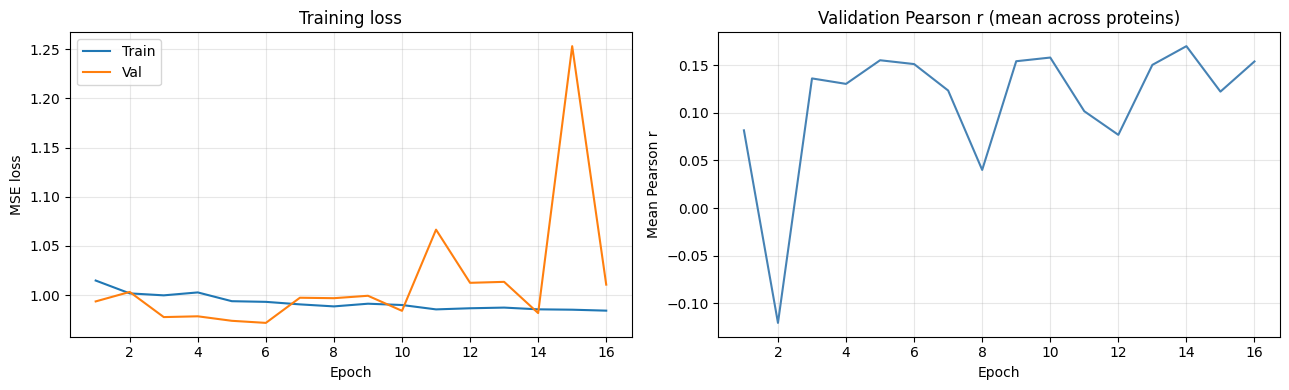

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE loss')
axes[0].set_title('Training loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_pearson'], color='steelblue')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean Pearson r')
axes[1].set_title('Validation Pearson r (mean across proteins)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. SHAP-Based Gene Importance

SHAP is run on the **pathway stream only** (mapped genes). The unmapped genes
flow through a dense MLP whose weights are less interpretable — including them
in SHAP would conflate two fundamentally different architectures.

The `MappedWrapper` class fixes the unmapped tensor to the background mean,
exposing only the mapped gene axis to the explainer. This gives clean,
pathway-grounded importance scores identical in interpretation to v1.


In [16]:
def compute_gene_shap_importance(model, train_loader,
                                 n_background=256, n_explain=512,
                                 device=DEVICE):
    """
    Compute per-gene SHAP importance for the mapped (pathway) stream.

    The unmapped stream is held fixed at background-mean values so the
    explainer attributes importance only to mapped gene inputs.

    Returns
    -------
    importance : np.ndarray, shape (n_mapped_genes,)
    """
    model.eval()

    all_Xm, all_Xu = [], []
    for Xm, Xu, _ in train_loader:
        all_Xm.append(Xm); all_Xu.append(Xu)
        if sum(x.shape[0] for x in all_Xm) >= n_background + n_explain:
            break

    all_Xm = torch.cat(all_Xm, dim=0)
    all_Xu = torch.cat(all_Xu, dim=0)

    bg_Xm  = all_Xm[:n_background].to(device)
    bg_Xu  = all_Xu[:n_background].to(device)
    ex_Xm  = all_Xm[n_background : n_background + n_explain].to(device)
    ex_Xu  = all_Xu[n_background : n_background + n_explain].to(device)

    # Fix unmapped stream to background mean — expose only mapped genes to SHAP
    fixed_Xu = bg_Xu.mean(dim=0, keepdim=True).expand(ex_Xm.shape[0], -1)

    class MappedWrapper(nn.Module):
        """Wraps DualBINNEncoder, fixing the unmapped input for SHAP."""
        def __init__(self, model, fixed_Xu):
            super().__init__()
            self.model    = model
            self.fixed_Xu = fixed_Xu
        def forward(self, Xm):
            return self.model(Xm, self.fixed_Xu)

    wrapper   = MappedWrapper(model, fixed_Xu)
    explainer = shap.GradientExplainer(wrapper, bg_Xm)

    print(f'GradientExplainer: {ex_Xm.shape[0]} samples, '
          f'{bg_Xm.shape[0]} background, {ex_Xm.shape[1]} mapped genes ...')

    shap_values = explainer.shap_values(ex_Xm)
    sv = np.array(shap_values)
    print(f'  Raw SHAP array shape: {sv.shape}')

    if sv.ndim == 3:
        importance = (np.abs(sv).mean(axis=(0, 2))
                      if sv.shape[0] == ex_Xm.shape[0]
                      else np.abs(sv).mean(axis=(0, 1)))
    else:
        importance = np.abs(sv).mean(axis=0)

    importance = importance.flatten()
    assert importance.shape[0] == ex_Xm.shape[1], (
        f'Shape mismatch: importance={importance.shape}, '
        f'n_mapped={ex_Xm.shape[1]}')

    print(f'  Importance shape: {importance.shape}')
    return importance


gene_shap = compute_gene_shap_importance(
    model, train_loader,
    n_background = N_SHAP_BACKGROUND,
    n_explain    = N_SHAP_EXPLAIN,
    device       = DEVICE,
)


GradientExplainer: 512 samples, 256 background ...
  Raw SHAP array shape: (512, 10418, 44)
  Importance shape: (10418,)


## 8. Gene Selection

In [17]:
importance_df = pd.DataFrame({
    'gene':            binn_input_genes,
    'shap_importance': gene_shap,
}).sort_values('shap_importance', ascending=False).reset_index(drop=True)

importance_df['shap_rank'] = range(1, len(importance_df) + 1)

importance_df.to_csv(OUTPUT_DIR / 'gene_shap_importance.csv', index=False)
print('Top 20 genes by SHAP importance:')
print(importance_df.head(20).to_string(index=False))


Top 20 genes by SHAP importance:
  gene  shap_importance  shap_rank
ZNF711         0.012131          1
ZNF664         0.011693          2
ZNF493         0.009411          3
ZNF254         0.008807          4
ZNF300         0.008318          5
  CCNC         0.006624          6
ZNF704         0.006511          7
ZNF559         0.005273          8
  CD14         0.005263          9
 ZFP90         0.005242         10
ZNF75A         0.005105         11
ZNF285         0.004940         12
  MED4         0.004813         13
  CDH2         0.004807         14
ZNF730         0.004700         15
ZNF519         0.004627         16
 ZNF25         0.004610         17
  CDK8         0.004435         18
ZNF268         0.004402         19
  MED1         0.004267         20


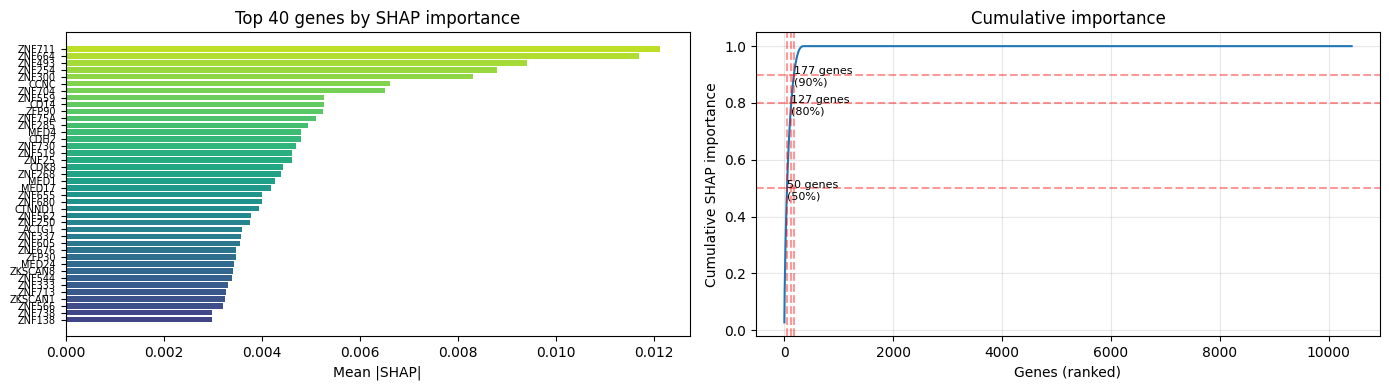

  50% importance → top 50 genes
  80% importance → top 127 genes
  90% importance → top 177 genes
  95% importance → top 218 genes


In [18]:
# Cumulative importance curve
cum = np.cumsum(importance_df['shap_importance'].values)
cum = cum / cum[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top40 = importance_df.head(40)
axes[0].barh(top40['gene'][::-1], top40['shap_importance'][::-1],
             color=cm.viridis(np.linspace(0.2, 0.9, 40)))
axes[0].set_xlabel('Mean |SHAP|')
axes[0].set_title('Top 40 genes by SHAP importance')
axes[0].tick_params(axis='y', labelsize=7)

axes[1].plot(range(1, len(cum) + 1), cum, lw=1.5)
for frac in [0.5, 0.8, 0.9]:
    n = np.searchsorted(cum, frac) + 1
    axes[1].axhline(frac, color='red', ls='--', alpha=0.4)
    axes[1].axvline(n,    color='red', ls='--', alpha=0.4)
    axes[1].text(n + 2, frac - 0.04, f'{n} genes\n({int(frac*100)}%)', fontsize=8)
axes[1].set_xlabel('Genes (ranked)')
axes[1].set_ylabel('Cumulative SHAP importance')
axes[1].set_title('Cumulative importance'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gene_importance.png', dpi=150, bbox_inches='tight')
plt.show()

for frac in [0.5, 0.8, 0.9, 0.95]:
    n = np.searchsorted(cum, frac) + 1
    print(f'  {int(frac*100)}% importance → top {n} genes')


Elbow point: 992 genes


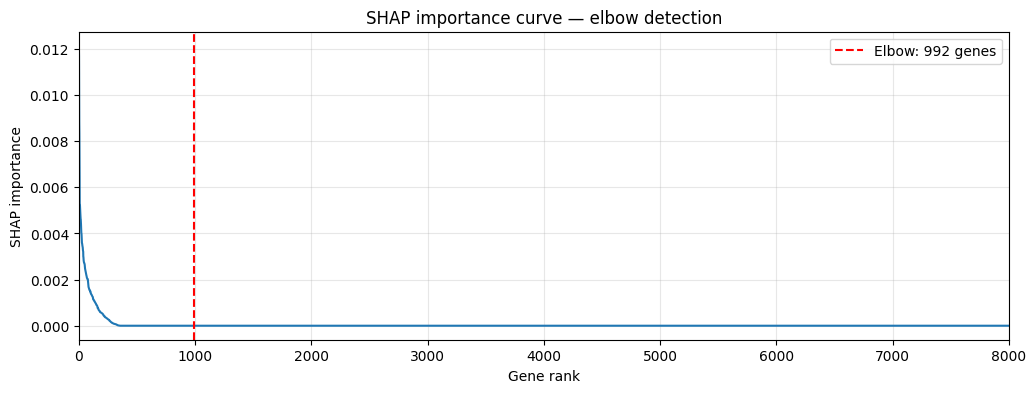

Selected 992 genes (data-driven elbow).


In [19]:
from kneed import KneeLocator

sorted_imp = importance_df['shap_importance'].values  # already sorted descending

knee = KneeLocator(
    x             = range(1, len(sorted_imp) + 1),
    y             = sorted_imp,
    curve         = 'convex',
    direction     = 'decreasing',
    interp_method = 'polynomial',
)

elbow_point = knee.knee
print(f'Elbow point: {elbow_point} genes')

# Visualise
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(1, len(sorted_imp) + 1), sorted_imp, lw=1.5)
ax.axvline(elbow_point, color='red', ls='--', label=f'Elbow: {elbow_point} genes')
ax.set_xlabel('Gene rank'); ax.set_ylabel('SHAP importance')
ax.set_title('SHAP importance curve — elbow detection')
ax.legend(); ax.set_xlim(0, 8000); ax.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / 'gene_importance.png', dpi=150, bbox_inches='tight')
plt.show()

SELECTED_GENES = importance_df.head(elbow_point)['gene'].tolist()
print(f'Selected {len(SELECTED_GENES)} genes (data-driven elbow).')

## 9. Output: Filtered h5ad

The output file preserves the **complete original AnnData structure** — all bins, all obs metadata (`array_row`, `array_col`, `pxl_*`, `in_tissue`, spatial coordinates) — but reduces the gene axis to the selected subset only.

| Layer / slot | Contents |
|---|---|
| `.X` | log-normalised expression (bins × selected genes) |
| `.layers['counts']` | raw UMI counts (bins × selected genes) |
| `.obs` | all original bin metadata unchanged |
| `.var` | gene names + `shap_importance` + `shap_rank` |
| `.uns['selected_genes']` | ordered list of selected gene names |
| `.uns['n_input_genes']` | original gene count (18,085) |

The function `write_filtered_h5ad` is designed to be called on **any** `.h5ad` that shares the same gene space (same 18,085 genes), so the identical gene selection can be applied to validation or test splits without re-running the BINN.

In [20]:
def write_filtered_h5ad(source_path, selected_genes, output_path,
                        normalize_target=1e4, importance_df=None):
    """
    Load an h5ad file and write a filtered copy containing only `selected_genes`.

    All bins (obs) and all obs metadata are preserved unchanged.
    Raw counts are stored in `.layers['counts']`; `.X` holds log-normalised values.
    SHAP importance scores are stored in `.var` if `importance_df` is provided.

    Parameters
    ----------
    source_path      : Path  — original .h5ad (must share the same gene space)
    selected_genes   : list[str]
    output_path      : Path
    normalize_target : float
    importance_df    : pd.DataFrame or None  — must have 'gene' and 'shap_importance'
    """
    print(f'Reading {source_path} ...')
    src = ad.read_h5ad(source_path, backed='r')
    print(f'  Original shape: {src.shape}')

    present = [g for g in selected_genes if g in src.var_names]
    missing = len(selected_genes) - len(present)
    if missing:
        print(f'  Warning: {missing} selected genes absent from this file — skipped.')

    # Slice gene axis; bring into RAM
    out = src[: , present].to_memory()

    # Store raw counts before normalisation
    out.layers['counts'] = (out.X.copy() if sp.issparse(out.X)
                            else sp.csr_matrix(out.X))

    # Normalise
    sc.pp.normalize_total(out, target_sum=normalize_target, inplace=True)
    sc.pp.log1p(out)

    # Annotate .var with SHAP scores if available
    if importance_df is not None:
        imp = importance_df.set_index('gene')
        out.var['shap_importance'] = [
            imp.loc[g, 'shap_importance'] if g in imp.index else np.nan
            for g in out.var_names
        ]
        out.var['shap_rank'] = [
            int(imp.loc[g, 'shap_rank']) if g in imp.index else -1
            for g in out.var_names
        ]

    # Provenance metadata
    out.uns['selected_genes']  = present
    out.uns['n_input_genes']   = src.shape[1]
    out.uns['n_selected_genes'] = len(present)

    out.write_h5ad(output_path)
    size_mb = output_path.stat().st_size / 1e6
    print(f'  Written: {output_path}  ({size_mb:.1f} MB)')
    print(f'  Genes: {src.shape[1]:,} → {len(present):,}  '
          f'({100 * len(present) / src.shape[1]:.1f}% retained)')
    return out


In [21]:
filtered_train = write_filtered_h5ad(
    source_path      = TRAIN_RNA_PATH,
    selected_genes   = SELECTED_GENES,
    output_path      = OUTPUT_DIR / 'train_rna_filtered.h5ad',
    normalize_target = NORMALIZE_TARGET,
    importance_df    = importance_df,
)

print('\nOutput AnnData structure:')
print(filtered_train)


Reading /home/ubuntu/data/train_rna.h5ad ...
  Original shape: (166186, 18085)
  Written: /home/ubuntu/data/outputs/train_rna_filtered.h5ad  (178.1 MB)
  Genes: 18,085 → 992  (5.5% retained)

Output AnnData structure:
AnnData object with n_obs × n_vars = 166186 × 992
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'split'
    var: 'gene_ids', 'feature_types', 'genome', 'shap_importance', 'shap_rank'
    uns: 'log1p', 'selected_genes', 'n_input_genes', 'n_selected_genes'
    layers: 'counts'


## 10. Save Model and Summary

In [22]:
# Save dual-stream BINN checkpoint with full metadata
torch.save({
    'model_state'    : model.state_dict(),
    'binn_input_genes': binn_input_genes,
    'unmapped_genes' : unmapped_genes,
    'selected_genes' : SELECTED_GENES,
    'layer_node_names': [list(l) for l in layer_nodes],
    'n_proteins'     : n_proteins,
    'dropout'        : DROPOUT_RATE,
    'training_config': {
        'N_BINN_LAYERS': N_BINN_LAYERS,
        'N_EPOCHS'     : N_EPOCHS,
        'BATCH_SIZE'   : BATCH_SIZE,
        'LEARNING_RATE': LEARNING_RATE,
    },
}, OUTPUT_DIR / 'binn_v2_model.pt')

# Save selected gene list
importance_df[importance_df['gene'].isin(SELECTED_GENES)].to_csv(
    OUTPUT_DIR / 'selected_genes.csv', index=False
)

print('=' * 55)
print('DUAL BINN FEATURE EXTRACTION — SUMMARY')
print('=' * 55)
print(f'Input genes (QC-passing)      : {len(all_genes):,}')
print(f'Stream 1 — Reactome-mapped    : {len(binn_input_genes):,}')
print(f'Stream 2 — Unmapped (dense)   : {len(unmapped_genes):,}')
print(f'Selected output genes (SHAP)  : {len(SELECTED_GENES):,}')
print(f'Best val MSE                  : {min(history["val_loss"]):.4f}')
print(f'Best val Pearson r            : {max(history["val_pearson"]):.3f}')
print()
print('Output files:')
for fname in ['train_rna_filtered.h5ad', 'selected_genes.csv',
              'gene_shap_importance.csv', 'binn_v2_model.pt',
              'training_curves.png', 'gene_importance.png']:
    p = OUTPUT_DIR / fname
    if p.exists():
        print(f'  {fname}  ({p.stat().st_size / 1e6:.1f} MB)')


BINN FEATURE EXTRACTION — SUMMARY
Input genes (QC-passing)   : 18,033
Genes with Reactome mapping: 10,418
BINN input genes           : 10,418
Selected output genes      : 992
Best val MSE               : 0.9718
Best val Pearson r         : 0.170

Output files:
  train_rna_filtered.h5ad  (178.1 MB)
  selected_genes.csv  (0.0 MB)
  gene_shap_importance.csv  (0.2 MB)
  binn_model.pt  (192.5 MB)
  training_curves.png  (0.1 MB)
  gene_importance.png  (0.0 MB)


In [23]:
print(f'Selected {len(SELECTED_GENES)} genes from {len(binn_input_genes)} BINN-input genes\n')
selected_df = importance_df[importance_df['gene'].isin(SELECTED_GENES)].copy()
print(selected_df[['shap_rank', 'gene', 'shap_importance']].to_string(index=False))

Selected 992 genes from 10418 BINN-input genes

 shap_rank      gene  shap_importance
         1    ZNF711     1.213141e-02
         2    ZNF664     1.169277e-02
         3    ZNF493     9.411113e-03
         4    ZNF254     8.807130e-03
         5    ZNF300     8.318020e-03
         6      CCNC     6.623812e-03
         7    ZNF704     6.511320e-03
         8    ZNF559     5.273496e-03
         9      CD14     5.263470e-03
        10     ZFP90     5.241834e-03
        11    ZNF75A     5.104595e-03
        12    ZNF285     4.940019e-03
        13      MED4     4.812833e-03
        14      CDH2     4.807281e-03
        15    ZNF730     4.699965e-03
        16    ZNF519     4.626556e-03
        17     ZNF25     4.609981e-03
        18      CDK8     4.435289e-03
        19    ZNF268     4.402450e-03
        20      MED1     4.267328e-03
        21     MED17     4.190521e-03
        22    ZNF655     4.011601e-03
        23    ZNF680     4.003604e-03
        24    CTNND1     3.938567e-03
  

## Appendix: Applying Gene Selection to Other Splits

Because `write_filtered_h5ad` only requires the source `.h5ad` and the `SELECTED_GENES` list, the same gene selection can be applied to any split that shares the same 18,085-gene space — no retraining required.

```python
# Example: apply to validation set
write_filtered_h5ad(
    source_path    = BASE_DIR / 'valid_rna.h5ad',
    selected_genes = SELECTED_GENES,
    output_path    = OUTPUT_DIR / 'valid_rna_filtered.h5ad',
    importance_df  = importance_df,
)

# Example: apply to test set
write_filtered_h5ad(
    source_path    = BASE_DIR / 'test_rna.h5ad',
    selected_genes = SELECTED_GENES,
    output_path    = OUTPUT_DIR / 'test_rna_filtered.h5ad',
    importance_df  = importance_df,
)
```

To reload the filtered file and inspect it:

```python
import anndata as ad
adata = ad.read_h5ad('outputs/train_rna_filtered.h5ad')

# Log-normalised expression matrix
X_norm = adata.X                          # (n_bins, n_selected_genes)

# Raw counts
X_raw  = adata.layers['counts']          # (n_bins, n_selected_genes)

# Spatial coordinates
coords = adata.obs[['array_row', 'array_col']]

# Selected gene names with importance
print(adata.var[['shap_importance', 'shap_rank']].head(10))
```
